# Pairwise rank comparison scatterplots

For each pair of metrics (Half Edge, Dissimilarity, Moran's I), plot cities by their score ranks against each other.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

In [6]:
# CSV_PATHS = ["../../outputs/tracts_in_max_city/white_poc.csv"]
CSV_PATHS = ["../../outputs/tracts_in_max_city/white_black.csv"]
    

METRICS = {"half_edge_1": "Half Edge (λ=1)",
    "dissimilarity_1": "Dissimilarity",
    "moran_P": "Moran's I",
    "filename": "filename",
    "total_population": "total_population"}
DISPLAY_METRICS = {"half_edge_1": "Half Edge (λ=1)",
    "dissimilarity_1": "Dissimilarity",
    "moran_P": "Moran's I",}

SELECTED_YEAR = '2020'
GROUPS_COMPARED = re.search(r'([^/]+)\.csv$', CSV_PATHS[0]).group(1) # white_black
if GROUPS_COMPARED == 'white_black':
    GROUPS_COMPARED = 'White and Black'
else:
    GROUPS_COMPARED = 'White and POC'
NODE_AREAS = re.search(r'outputs/([^_]+)_in', CSV_PATHS[0]).group(1) # tracts
STUDY_AREAS = re.search(r'outputs/[^/]+_in_([^/]+)/', CSV_PATHS[0]).group(1) # max_city
if STUDY_AREAS == 'max_city':
    STUDY_AREAS = 'the largest city per metropolitan area'

In [7]:
# load and tag each file with a label derived from its path
frames = []
for path in CSV_PATHS:
    df = pd.read_csv(path, usecols=list(METRICS))
    df["source"] = path.split("/")[-1].replace(".csv", "")
    df["year"] = df["filename"].str.extract(r'(\d{4})')
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data = data.dropna(subset=list(METRICS))

# subset to one year, select top 100 by population
data = data[data['year'] == SELECTED_YEAR]
data = data.sort_values("total_population", ascending=False)[:100]

# rank within each source file
# del METRICS['filename']
for col in DISPLAY_METRICS:
    data[col + "_rank"] = data.groupby("source")[col].rank(method="average")

data.head(3)

,filename,half_edge_1,dissimilarity_1,moran_P,total_population,source,year,half_edge_1_rank,dissimilarity_1_rank,moran_P_rank
1589,data/processed/dual_graphs/2020/tracts_in_max_...,0.815213,0.775780,0.861760,8804129,white_black,2020,99.0,99.0,95.0
1411,data/processed/dual_graphs/2020/tracts_in_max_...,0.723462,0.622384,0.921198,3879359,white_black,2020,90.0,83.0,100.0
1483,data/processed/dual_graphs/2020/tracts_in_max_...,0.856471,0.818493,0.897334,2688186,white_black,2020,100.0,100.0,99.0


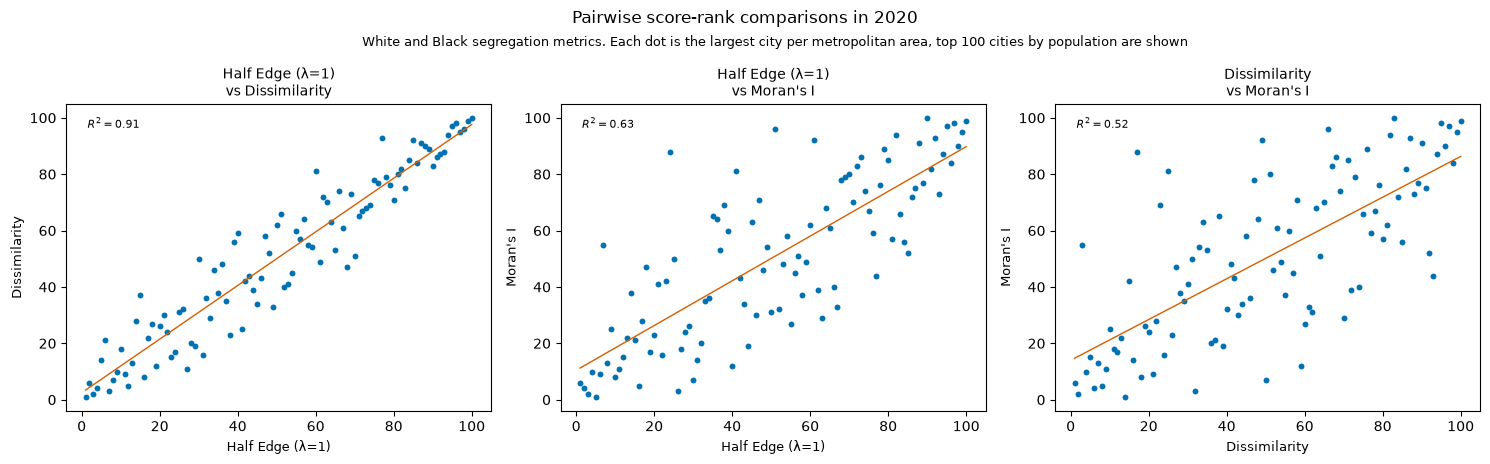

In [8]:
pairs = list(combinations(DISPLAY_METRICS.keys(), 2)) # 3 pairs
sources = data["source"].unique()
colors = ["#0072b2", "#d55e00", "#009e73", "#cc79a7"]

fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))

for ax, (x_col, y_col) in zip(axes, pairs):
    for i, src in enumerate(sources):
        sub = data[data["source"] == src]
        ax.scatter(sub[x_col + "_rank"], sub[y_col + "_rank"],
            s=18, alpha=1,
            color=colors[i % len(colors)],
            label=src, linewidths=0)
        x = sub[x_col + "_rank"]
        y = sub[y_col + "_rank"]
        m, b = np.polyfit(x, y, 1)
        r2 = np.corrcoef(x, y)[0, 1] ** 2
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m * xline + b, color=colors[1], lw=1)
        ax.annotate(f"$R^2={r2:.2f}$", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=8)


    ax.set_xlabel(DISPLAY_METRICS[x_col], fontsize=9)
    ax.set_ylabel(DISPLAY_METRICS[y_col], fontsize=9)
    ax.set_title(f"{DISPLAY_METRICS[x_col]}\nvs {DISPLAY_METRICS[y_col]}", fontsize=10)

# legend outside the last panel
# handles, labels = axes[-1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower center", ncol=len(sources),
#            bbox_to_anchor=(0.5, -0.05), fontsize=9, frameon=False)
# fig.suptitle(f"Top 100 cities by population. Year: {SELECTED_YEAR}.", fontsize=12, y=1.02)
fig.text(0.52, 0.94, f"{GROUPS_COMPARED} segregation metrics. Each dot is {STUDY_AREAS}, top 100 cities by population are shown", 
         ha="center", fontsize=9)


fig.suptitle(f"Pairwise score-rank comparisons in {SELECTED_YEAR}", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()